<a href="https://colab.research.google.com/github/sorotdaniel/portfolio-soro/blob/main/heraldine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import json
import csv
import pandas as pd
# Charger le fichier JSON, en traitant chaque ligne comme un objet JSON distinct
data = []
with open("heraldine.json", "r", encoding="utf-8") as f:
    for line in f:
        try:
            data.append(json.loads(line))  # Charger chaque ligne comme un objet JSON
        except json.JSONDecodeError as e:
            print(f"Erreur lors du chargement de la ligne : {line.strip()}")
            print(f"Détails de l'erreur : {e}")

# Ouvrir le fichier CSV pour l'écriture
with open("heraldine.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    # Écrire l'en-tête (si des données ont été chargées)
    if data:
        header = data[0].keys()
        writer.writerow(header)

        # Écrire les lignes
        for row in data:
            writer.writerow(row.values())
    else:
        print("Aucune donnée JSON valide n'a été trouvée dans le fichier.")

In [6]:
heraldine = pd.DataFrame(data)
heraldine.head()

,timestamp,duration,session_id,source_ip,source_port,destination_ip,destination_port,protocol,num_auth_attempts,auth_attempts,session_ended,auxiliary_data
0,2025-04-05 02:00:59.985785,0,75e76558-25fd-44c0-9a6a-3189acf0b589,193.36.225.119,17759,132.213.238.62,443,https,0,[],True,{}
1,2025-04-05 02:02:07.050311,0,e260b573-9e99-44c9-9cf5-bed4ede87724,80.94.95.210,46390,132.213.238.62,443,https,0,[],True,{}
2,2025-04-05 02:02:39.466233,0,41d3cc2f-e646-423e-be95-1b45656fb47c,221.231.8.18,46930,132.213.238.62,5900,vnc,0,[],True,{}
3,2025-04-05 02:03:09.712475,0,f4fd110c-50ae-4b6c-9495-14eff2737b6f,185.194.178.40,2570,132.213.238.62,443,https,0,[],True,{}
4,2025-04-05 02:04:27.705051,0,b6e77a4f-3c78-4f98-9f3c-f80f93ea153a,193.36.225.119,9290,132.213.238.62,443,https,0,[],True,{}


In [7]:
heraldine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40646 entries, 0 to 40645
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   timestamp          40646 non-null  object
 1   duration           40646 non-null  int64 
 2   session_id         40646 non-null  object
 3   source_ip          40646 non-null  object
 4   source_port        40646 non-null  int64 
 5   destination_ip     40646 non-null  object
 6   destination_port   40646 non-null  int64 
 7   protocol           40646 non-null  object
 8   num_auth_attempts  40646 non-null  int64 
 9   auth_attempts      40646 non-null  object
 10  session_ended      40646 non-null  bool  
 11  auxiliary_data     40646 non-null  object
dtypes: bool(1), int64(4), object(7)
memory usage: 3.5+ MB


# Visualisation des valeurs manquantes

In [8]:
for col in heraldine.columns:
  val_manquant = heraldine[col].isna().sum()
  print(col,'-----', val_manquant)

timestamp ----- 0
duration ----- 0
session_id ----- 0
source_ip ----- 0
source_port ----- 0
destination_ip ----- 0
destination_port ----- 0
protocol ----- 0
num_auth_attempts ----- 0
auth_attempts ----- 0
session_ended ----- 0
auxiliary_data ----- 0


# encodage des variables

In [9]:
for col in heraldine.columns:
  print(heraldine[col].value_counts())


timestamp
2025-04-08 04:11:41.013179    1
2025-04-05 02:00:59.985785    1
2025-04-05 02:02:07.050311    1
2025-04-05 02:02:39.466233    1
2025-04-05 02:03:09.712475    1
                             ..
2025-04-05 02:07:03.937355    1
2025-04-05 02:06:41.893657    1
2025-04-05 02:06:21.418267    1
2025-04-05 02:05:59.184779    1
2025-04-05 02:05:37.173293    1
Name: count, Length: 40646, dtype: int64
duration
3     9100
0     7485
2     7430
1     4895
30    4454
4     2303
5      853
6      614
7      489
8      329
9      242
11     228
12     225
29     219
10     213
22     175
13     170
21     167
14     151
23     136
15     106
20     100
24      96
19      77
25      76
16      74
18      57
17      55
26      51
27      41
28      35
Name: count, dtype: int64
session_id
84d6c76e-bedd-46c7-9c9a-953f312348e0    1
75e76558-25fd-44c0-9a6a-3189acf0b589    1
e260b573-9e99-44c9-9cf5-bed4ede87724    1
41d3cc2f-e646-423e-be95-1b45656fb47c    1
f4fd110c-50ae-4b6c-9495-14eff2737b6f    1


In [10]:
heraldine.timestamp.nunique()

40646

In [11]:
heraldine.session_id.nunique()

40646

In [12]:
#heraldine.drop(['timestamp','session_id'], axis=1, inplace=True)


In [13]:
heraldine.head(30)

,timestamp,duration,session_id,source_ip,source_port,destination_ip,destination_port,protocol,num_auth_attempts,auth_attempts,session_ended,auxiliary_data
0,2025-04-05 02:00:59.985785,0,75e76558-25fd-44c0-9a6a-3189acf0b589,193.36.225.119,17759,132.213.238.62,443,https,0,[],True,{}
1,2025-04-05 02:02:07.050311,0,e260b573-9e99-44c9-9cf5-bed4ede87724,80.94.95.210,46390,132.213.238.62,443,https,0,[],True,{}
2,2025-04-05 02:02:39.466233,0,41d3cc2f-e646-423e-be95-1b45656fb47c,221.231.8.18,46930,132.213.238.62,5900,vnc,0,[],True,{}
3,2025-04-05 02:03:09.712475,0,f4fd110c-50ae-4b6c-9495-14eff2737b6f,185.194.178.40,2570,132.213.238.62,443,https,0,[],True,{}
4,2025-04-05 02:04:27.705051,0,b6e77a4f-3c78-4f98-9f3c-f80f93ea153a,193.36.225.119,9290,132.213.238.62,443,https,0,[],True,{}
5,2025-04-05 02:05:58.694655,0,4ff2ef04-5af7-4c42-8d04-656aa6436358,185.194.178.40,44466,132.213.238.62,443,https,0,[],True,{}
6,2025-04-05 02:05:37.173293,30,86b08836-87a5-4dd8-954b-a0cd685d420b,60.246.82.220,47420,132.213.238.62,23,telnet,0,[],True,{}
7,2025-04-05 02:05:59.184779,18,f8dc0467-339c-4e3f-8a2c-083de13f1d65,60.246.82.220,49052,132.213.238.62,23,telnet,3,"[{'timestamp': '2025-04-05 02:06:06.847819', '...",True,{}
8,2025-04-05 02:06:21.418267,17,891a018b-257d-47a7-a7f1-dabee7b8cc28,60.246.82.220,59092,132.213.238.62,23,telnet,3,"[{'timestamp': '2025-04-05 02:06:28.494342', '...",True,{}
9,2025-04-05 02:06:41.893657,19,a8e4dd69-e6c8-4281-9e29-4190c430782b,60.246.82.220,44034,132.213.238.62,23,telnet,3,"[{'timestamp': '2025-04-05 02:06:50.290703', '...",True,{}


In [14]:
import pandas as pd
import re

In [15]:
aut = heraldine.auth_attempts

In [16]:
raw_data = heraldine['auth_attempts']
raw_data

,auth_attempts
0,[]
1,[]
2,[]
3,[]
4,[]
...,...
40641,[]
40642,[]
40643,[]
40644,[]


In [18]:
heraldine.auxiliary_data.value_counts()


,count
auxiliary_data,
"{'client_version': 'SSH-2.0-libssh_0.7.4', 'recv_cipher': 'aes256-ctr', 'recv_mac': 'hmac-sha2-256', 'recv_compression': 'none'}",26714
{},4625
"{'client_version': 'SSH-2.0-libssh2_1.11.1', 'recv_cipher': 'chacha20-poly1305@openssh.com', 'recv_mac': 'chacha20-poly1305@openssh.com', 'recv_compression': 'none'}",4055
"{'client_version': None, 'recv_cipher': None, 'recv_mac': None, 'recv_compression': None}",2615
"{'client_version': 'SSH-2.0-libssh_0.7.4', 'recv_cipher': None, 'recv_mac': None, 'recv_compression': None}",2120
"{'client_version': 'SSH-2.0-libssh-0.2', 'recv_cipher': None, 'recv_mac': None, 'recv_compression': None}",186
"{'client_version': 'SSH-2.0-Go', 'recv_cipher': 'aes128-gcm@openssh.com', 'recv_mac': 'aes128-gcm@openssh.com', 'recv_compression': 'none'}",175
{'client_auth_methods': ['NO AUTHENTICATION REQUIRED']},85
"{'client_version': 'SSH-2.0-libssh_0.10.5', 'recv_cipher': 'aes256-gcm@openssh.com', 'recv_mac': 'aes256-gcm@openssh.com', 'recv_compression': 'none'}",29


In [19]:
df =heraldine.copy()

In [20]:
df.tail(5)

,timestamp,duration,session_id,source_ip,source_port,destination_ip,destination_port,protocol,num_auth_attempts,auth_attempts,session_ended,auxiliary_data
40641,2025-04-08 04:11:26.395056,0,f05278ce-ab6e-481e-99e6-0014cf372147,185.194.178.94,59093,132.213.238.62,443,https,0,[],True,{}
40642,2025-04-08 04:11:26.403848,4,b2550b6c-4532-4c43-b528-eba74670e1b0,118.31.244.45,52922,132.213.238.62,22,ssh,0,[],True,"{'client_version': 'SSH-2.0-libssh_0.7.4', 're..."
40643,2025-04-08 04:11:31.280335,4,28afa856-0b4c-43a7-8198-35944857c670,118.31.244.45,60322,132.213.238.62,22,ssh,0,[],True,"{'client_version': 'SSH-2.0-libssh_0.7.4', 're..."
40644,2025-04-08 04:11:36.003583,3,91282e09-26f3-417b-b6b5-2fb85dd6106d,118.31.244.45,36854,132.213.238.62,22,ssh,0,[],True,"{'client_version': 'SSH-2.0-libssh_0.7.4', 're..."
40645,2025-04-08 04:11:41.013179,4,84d6c76e-bedd-46c7-9c9a-953f312348e0,118.31.244.45,42654,132.213.238.62,22,ssh,0,[],True,"{'client_version': 'SSH-2.0-libssh_0.7.4', 're..."


# traitement de la colonne auxiliary_data


In [21]:
# Process auxiliary_data BEFORE label encoding
import ast # Import ast here as it's used in this section
import pandas as pd # Ensure pandas is imported if not already

# Check if 'auxiliary_data' column exists before processing
if 'auxiliary_data' in heraldine.columns:
    # Handle potential non-string values and empty strings in auxiliary_data
    # Replace NaN with a default string representation of an empty dictionary or handle them as appropriate
    # If NaN should result in an empty dictionary:
    heraldine['auxiliary_data'] = heraldine['auxiliary_data'].fillna('{ }')
    # Ensure all values are strings before applying literal_eval
    heraldine['auxiliary_data'] = heraldine['auxiliary_data'].astype(str)

    # Convert strings to dictionaries, handling potential errors
    def safe_literal_eval(val):
        try:
            return ast.literal_eval(val)
        except (SyntaxError, ValueError):
            # Return an empty dictionary or another indicator for invalid entries
            return {}
        except TypeError:
            # Handle cases where the input is not a string (though we cast to str above)
             return {}

    heraldine["auxiliary_data_dict"] = heraldine["auxiliary_data"].apply(safe_literal_eval)

    # Normalize the dictionaries into new columns
    aux_data_normalized = pd.json_normalize(heraldine["auxiliary_data_dict"])

    # You might want to drop the original 'auxiliary_data' column and the intermediate 'auxiliary_data_dict'
    # Ensure you drop only if the columns exist
    cols_to_drop = ['auxiliary_data', 'auxiliary_data_dict']
    cols_to_drop_existing = [col for col in cols_to_drop if col in heraldine.columns]
    heraldine = pd.concat([heraldine, aux_data_normalized], axis=1)
    heraldine = heraldine.drop(cols_to_drop_existing, axis=1)

    print("Processed and dropped 'auxiliary_data' column.")
else:
    print("'auxiliary_data' column not found. Assuming it has already been processed or dropped.")


print(heraldine.head())
print(heraldine.info())

Processed and dropped 'auxiliary_data' column.
                    timestamp  duration                            session_id  \
0  2025-04-05 02:00:59.985785         0  75e76558-25fd-44c0-9a6a-3189acf0b589   
1  2025-04-05 02:02:07.050311         0  e260b573-9e99-44c9-9cf5-bed4ede87724   
2  2025-04-05 02:02:39.466233         0  41d3cc2f-e646-423e-be95-1b45656fb47c   
3  2025-04-05 02:03:09.712475         0  f4fd110c-50ae-4b6c-9495-14eff2737b6f   
4  2025-04-05 02:04:27.705051         0  b6e77a4f-3c78-4f98-9f3c-f80f93ea153a   

        source_ip  source_port  destination_ip  destination_port protocol  \
0  193.36.225.119        17759  132.213.238.62               443    https   
1    80.94.95.210        46390  132.213.238.62               443    https   
2    221.231.8.18        46930  132.213.238.62              5900      vnc   
3  185.194.178.40         2570  132.213.238.62               443    https   
4  193.36.225.119         9290  132.213.238.62               443    https   

   

# traitement de la variable auth_attempts        

In [22]:
heraldine.auth_attempts.value_counts()

,count
auth_attempts,
[],36315
"[{'timestamp': '2025-04-05 17:19:15.547659', 'username': 'root', 'password': 'manchester1'}]",1
"[{'timestamp': '2025-04-05 17:19:14.412699', 'username': 'irc', 'password': 'irc'}]",1
"[{'timestamp': '2025-04-05 17:19:13.061615', 'username': 'root', 'password': 'Abcd1234!@#$'}]",1
"[{'timestamp': '2025-04-05 17:19:11.693109', 'username': 'arma3sync', 'password': 'arma3sync'}]",1
...,...
"[{'timestamp': '2025-04-05 16:34:55.081260', 'username': 'root', 'password': 'asd!@#'}]",1
"[{'timestamp': '2025-04-05 16:34:53.932279', 'username': 'database', 'password': 'database'}]",1
"[{'timestamp': '2025-04-05 16:34:52.582417', 'username': 'root', 'password': '123456789'}]",1


In [23]:
# Filtrer les lignes où 'auth_attempts' est une liste vide ou n'est pas une liste
filtered_heraldine = heraldine[heraldine['auth_attempts'].apply(lambda x: isinstance(x, list) and len(x) > 0)]

# Créer maintenant le DataFrame df_auth à partir du DataFrame filtré
df_auth = pd.DataFrame([x[0] for x in filtered_heraldine['auth_attempts']])


In [24]:
heraldine = pd.concat([df_auth, heraldine], axis=1)
heraldine.head()

,timestamp,username,password,timestamp,duration,session_id,source_ip,source_port,destination_ip,destination_port,protocol,num_auth_attempts,auth_attempts,session_ended,client_auth_methods,client_version,recv_cipher,recv_mac,recv_compression
0,2025-04-05 02:06:06.847819,default,1cDuLJ7c,2025-04-05 02:00:59.985785,0,75e76558-25fd-44c0-9a6a-3189acf0b589,193.36.225.119,17759,132.213.238.62,443,https,0,[],True,NaN,NaN,NaN,NaN,NaN
1,2025-04-05 02:06:28.494342,admin,admin123,2025-04-05 02:02:07.050311,0,e260b573-9e99-44c9-9cf5-bed4ede87724,80.94.95.210,46390,132.213.238.62,443,https,0,[],True,NaN,NaN,NaN,NaN,NaN
2,2025-04-05 02:06:50.290703,default,1cDuLJ7c,2025-04-05 02:02:39.466233,0,41d3cc2f-e646-423e-be95-1b45656fb47c,221.231.8.18,46930,132.213.238.62,5900,vnc,0,[],True,NaN,NaN,NaN,NaN,NaN
3,2025-04-05 02:07:11.578273,root,1001chin,2025-04-05 02:03:09.712475,0,f4fd110c-50ae-4b6c-9495-14eff2737b6f,185.194.178.40,2570,132.213.238.62,443,https,0,[],True,NaN,NaN,NaN,NaN,NaN
4,2025-04-05 02:07:33.224949,ftp,ftp,2025-04-05 02:04:27.705051,0,b6e77a4f-3c78-4f98-9f3c-f80f93ea153a,193.36.225.119,9290,132.213.238.62,443,https,0,[],True,NaN,NaN,NaN,NaN,NaN


In [25]:
heraldine.num_auth_attempts.value_counts()

,count
num_auth_attempts,
0,36315
1,4267
3,57
2,6
6,1


In [26]:
heraldine.drop(['timestamp', 'auth_attempts'], axis=1, inplace=True)


In [27]:
heraldine

,username,password,duration,session_id,source_ip,source_port,destination_ip,destination_port,protocol,num_auth_attempts,session_ended,client_auth_methods,client_version,recv_cipher,recv_mac,recv_compression
0,default,1cDuLJ7c,0,75e76558-25fd-44c0-9a6a-3189acf0b589,193.36.225.119,17759,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
1,admin,admin123,0,e260b573-9e99-44c9-9cf5-bed4ede87724,80.94.95.210,46390,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
2,default,1cDuLJ7c,0,41d3cc2f-e646-423e-be95-1b45656fb47c,221.231.8.18,46930,132.213.238.62,5900,vnc,0,True,NaN,NaN,NaN,NaN,NaN
3,root,1001chin,0,f4fd110c-50ae-4b6c-9495-14eff2737b6f,185.194.178.40,2570,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
4,ftp,ftp,0,b6e77a4f-3c78-4f98-9f3c-f80f93ea153a,193.36.225.119,9290,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,NaN,NaN,0,f05278ce-ab6e-481e-99e6-0014cf372147,185.194.178.94,59093,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
40642,NaN,NaN,4,b2550b6c-4532-4c43-b528-eba74670e1b0,118.31.244.45,52922,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
40643,NaN,NaN,4,28afa856-0b4c-43a7-8198-35944857c670,118.31.244.45,60322,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
40644,NaN,NaN,3,91282e09-26f3-417b-b6b5-2fb85dd6106d,118.31.244.45,36854,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none


# verification des relations entre les valeurs manquantes

In [28]:
!pip install pyampute

In [29]:
df = heraldine.copy()
df

,username,password,duration,session_id,source_ip,source_port,destination_ip,destination_port,protocol,num_auth_attempts,session_ended,client_auth_methods,client_version,recv_cipher,recv_mac,recv_compression
0,default,1cDuLJ7c,0,75e76558-25fd-44c0-9a6a-3189acf0b589,193.36.225.119,17759,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
1,admin,admin123,0,e260b573-9e99-44c9-9cf5-bed4ede87724,80.94.95.210,46390,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
2,default,1cDuLJ7c,0,41d3cc2f-e646-423e-be95-1b45656fb47c,221.231.8.18,46930,132.213.238.62,5900,vnc,0,True,NaN,NaN,NaN,NaN,NaN
3,root,1001chin,0,f4fd110c-50ae-4b6c-9495-14eff2737b6f,185.194.178.40,2570,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
4,ftp,ftp,0,b6e77a4f-3c78-4f98-9f3c-f80f93ea153a,193.36.225.119,9290,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,NaN,NaN,0,f05278ce-ab6e-481e-99e6-0014cf372147,185.194.178.94,59093,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
40642,NaN,NaN,4,b2550b6c-4532-4c43-b528-eba74670e1b0,118.31.244.45,52922,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
40643,NaN,NaN,4,28afa856-0b4c-43a7-8198-35944857c670,118.31.244.45,60322,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
40644,NaN,NaN,3,91282e09-26f3-417b-b6b5-2fb85dd6106d,118.31.244.45,36854,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none


In [30]:
df1 = df.copy()

### Test MCAR pour les valeurs manquantes completement aleatoires

In [31]:
'''
from pyampute import ampute  # Correct import for amputation
from pyampute.exploration import mcar_test

# Test MCAR
stat, pvalue = mcar_test(heraldine)
print(f"Statistique: {stat}, p-value: {pvalue}")

if pvalue > 0.05:
    print("Les données sont probablement MCAR.")
else:
    print("Les données ne sont probablement pas MCAR.")
'''

'\nfrom pyampute import ampute  # Correct import for amputation\nfrom pyampute.exploration import mcar_test\n\n# Test MCAR\nstat, pvalue = mcar_test(heraldine)\nprint(f"Statistique: {stat}, p-value: {pvalue}")\n\nif pvalue > 0.05:\n    print("Les données sont probablement MCAR.")\nelse:\n    print("Les données ne sont probablement pas MCAR.")\n'

### Test  d'independance de Chi deux pour les valeurs manquantes

In [32]:
df1['A_manquante'] = df['recv_compression'].isnull().astype(int)
df1['B_manquante'] = df['client_auth_methods'].isnull().astype(int)  # 1 si A est manquante, 0 sinon
print(df1['A_manquante'], df1['B_manquante'])

0        1
1        1
2        1
3        1
4        1
        ..
40641    1
40642    0
40643    0
40644    0
40645    0
Name: A_manquante, Length: 40646, dtype: int64 0        1
1        1
2        1
3        1
4        1
        ..
40641    1
40642    1
40643    1
40644    1
40645    1
Name: B_manquante, Length: 40646, dtype: int64


In [33]:
from scipy.stats import chi2_contingency
import pandas as pd

# Exemple : tester la relation entre "A_manquante" et "B"
table = pd.crosstab(df1['A_manquante'], df1['B_manquante'])
chi2_stat, p_val, dof, expected = chi2_contingency(table)

print(f"Chi2 = {chi2_stat:.2f}, p-value = {p_val:.4f}")
if p_val < 0.05:
    print("Relation significative : les valeurs manquantes de A dépendent de B.")
else:
    print("Pas de relation significative : les valeurs manquantes de A sont indépendantes de B.")


Chi2 = 275.46, p-value = 0.0000
Relation significative : les valeurs manquantes de A dépendent de B.


### Vérifier si les données manquent de manière aléatoire (test MCAR)

In [34]:
pip install missingpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 3.2 MB/s eta 0:00:00


In [37]:
!pip install scikit-learn==0.22.2.post1
!pip install missingpy


  Using cached scikit-learn-0.22.2.post1.tar.gz (6.9 MB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for scikit-learn
  Running setup.py clean for scikit-learn
Failed to build scikit-learn
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (scikit-learn)


<Axes: >

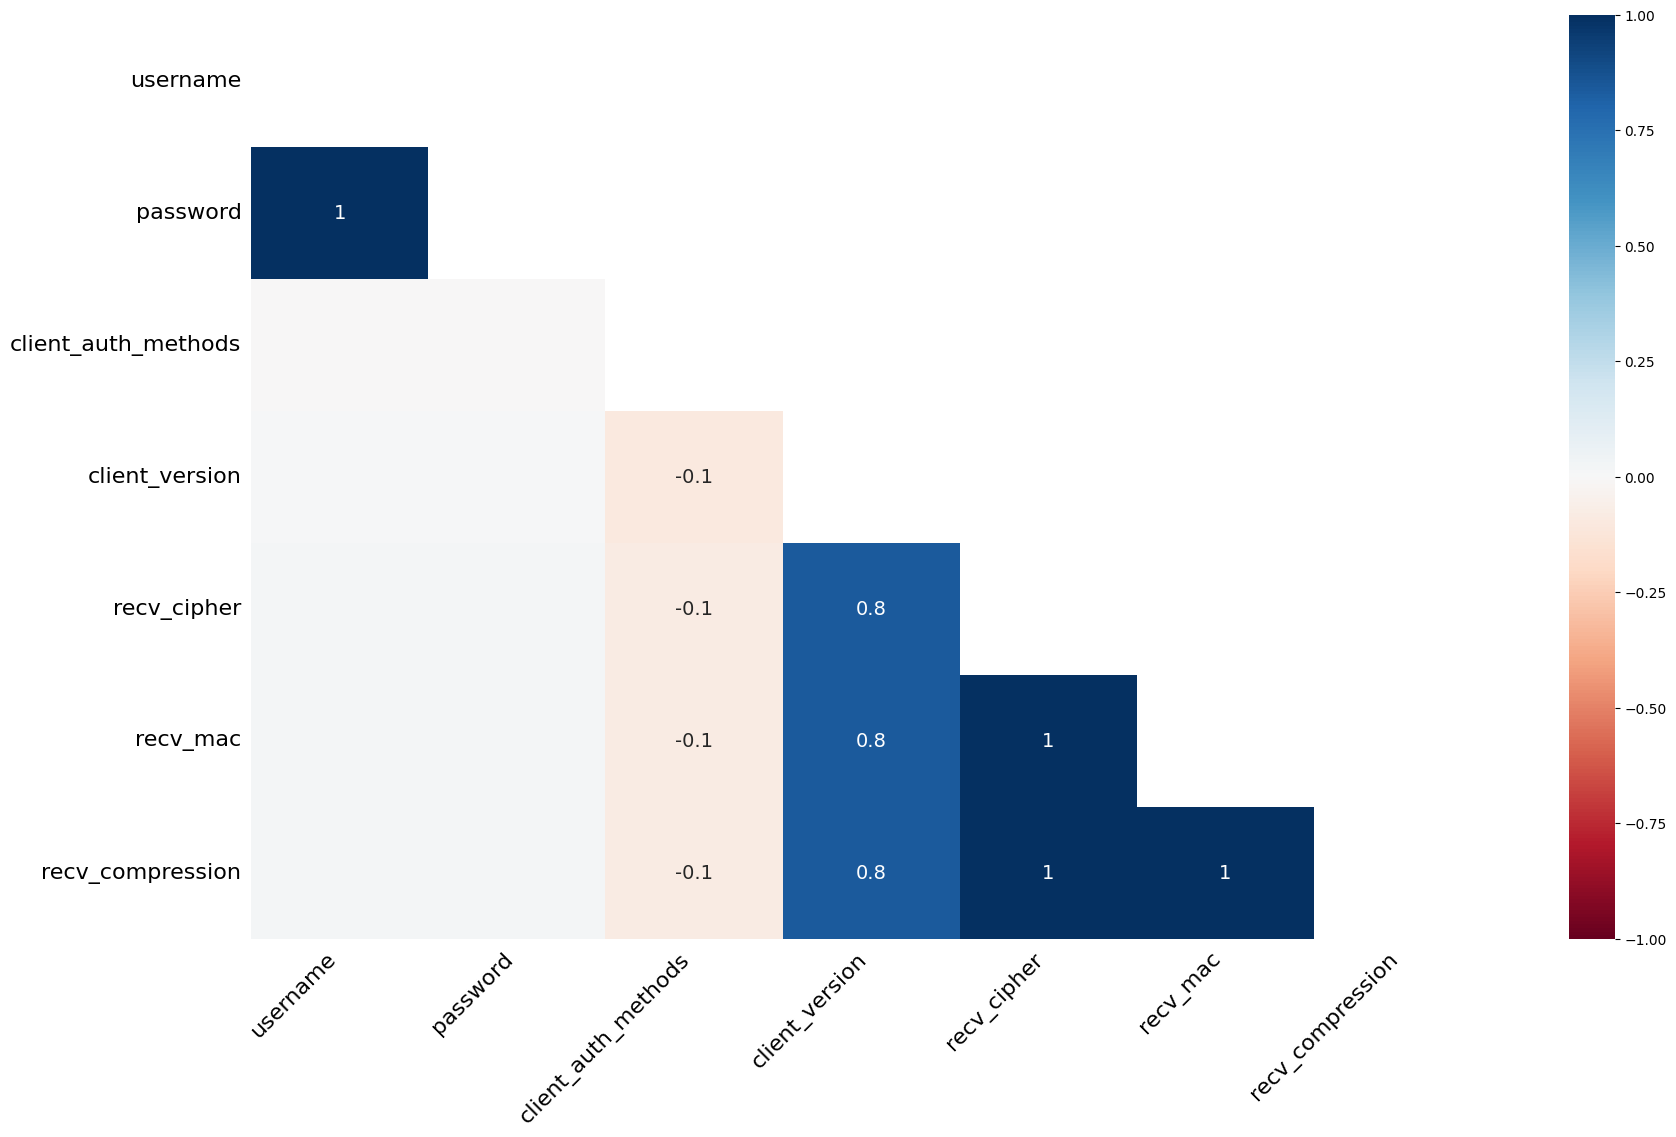

In [39]:
import missingno as msno
#Utile pour voir si certaines colonnes ont des patterns de valeurs manquantes similaires, ce qui suggère du MAR (Missing At Random)
msno.heatmap(df)

# appel de R

In [40]:
'''
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

df = pd.read_csv('chemin/vers/ton_fichier.csv')  # Charger tes données
msno.matrix(df)
plt.show()
'''

"\nimport pandas as pd\nimport missingno as msno\nimport matplotlib.pyplot as plt\n\ndf = pd.read_csv('chemin/vers/ton_fichier.csv')  # Charger tes données\nmsno.matrix(df)\nplt.show()\n"

In [ ]:
'''
import scipy.stats as stats

# Exemple : vérifier si la colonne A (avec valeurs manquantes) dépend de B
df['missing_A'] = df['client_auth_methods'].isnull().astype(int)
group1 = df[df['missing_A'] == 1]['client_version']
group2 = df[df['missing_A'] == 0]['client_version']

print(df['missing_A'].isnull().sum()) # ;'valeurs manquantes'
print((~df['missing_A'].isnull()).sum()) #; 'valeurs non manquantes'

t_stat, p_val = stats.ttest_ind(group1.dropna(), group2.dropna(), equal_var=False)
print(f"p-value pour dépendance entre A manquant et B : {p_val}")

if p_val < 0.05:
    print("Les données sont probablement MAR (dépendance détectée).")
else:
    print("Pas de dépendance détectée (peut-être MCAR).")
'''

'\nimport scipy.stats as stats\n\n# Exemple : vérifier si la colonne A (avec valeurs manquantes) dépend de B\ndf[\'missing_A\'] = df[\'client_auth_methods\'].isnull().astype(int)\ngroup1 = df[df[\'missing_A\'] == 1][\'client_version\']\ngroup2 = df[df[\'missing_A\'] == 0][\'client_version\']\n\nprint(df[\'missing_A\'].isnull().sum()) # ;\'valeurs manquantes\'\nprint((~df[\'missing_A\'].isnull()).sum()) #; \'valeurs non manquantes\'\n\nt_stat, p_val = stats.ttest_ind(group1.dropna(), group2.dropna(), equal_var=False)\nprint(f"p-value pour dépendance entre A manquant et B : {p_val}")\n\nif p_val < 0.05:\n    print("Les données sont probablement MAR (dépendance détectée).")\nelse:\n    print("Pas de dépendance détectée (peut-être MCAR).")\n'

In [41]:
heraldine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40646 entries, 0 to 40645
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   username             4331 non-null   object
 1   password             4330 non-null   object
 2   duration             40646 non-null  int64 
 3   session_id           40646 non-null  object
 4   source_ip            40646 non-null  object
 5   source_port          40646 non-null  int64 
 6   destination_ip       40646 non-null  object
 7   destination_port     40646 non-null  int64 
 8   protocol             40646 non-null  object
 9   num_auth_attempts    40646 non-null  int64 
 10  session_ended        40646 non-null  bool  
 11  client_auth_methods  87 non-null     object
 12  client_version       33319 non-null  object
 13  recv_cipher          30986 non-null  object
 14  recv_mac             30986 non-null  object
 15  recv_compression     30986 non-null  object
dtypes: b

In [ ]:
'''
# Convertir en objet datetime
import datetime
heraldine['timestamp'] = pd.to_datetime(heraldine['timestamp'])

# Extraire des caractéristiques temporelles
heraldine['hour'] = heraldine['timestamp'].dt.hour
heraldine['day_of_week'] = heraldine['timestamp'].dt.dayofweek
heraldine['month'] = heraldine['timestamp'].dt.month

print(heraldine[['timestamp', 'hour', 'day_of_week', 'month']])
'''

"\n# Convertir en objet datetime\nimport datetime\nheraldine['timestamp'] = pd.to_datetime(heraldine['timestamp'])\n\n# Extraire des caractéristiques temporelles\nheraldine['hour'] = heraldine['timestamp'].dt.hour\nheraldine['day_of_week'] = heraldine['timestamp'].dt.dayofweek\nheraldine['month'] = heraldine['timestamp'].dt.month\n\nprint(heraldine[['timestamp', 'hour', 'day_of_week', 'month']])\n"

In [42]:
heraldine

,username,password,duration,session_id,source_ip,source_port,destination_ip,destination_port,protocol,num_auth_attempts,session_ended,client_auth_methods,client_version,recv_cipher,recv_mac,recv_compression
0,default,1cDuLJ7c,0,75e76558-25fd-44c0-9a6a-3189acf0b589,193.36.225.119,17759,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
1,admin,admin123,0,e260b573-9e99-44c9-9cf5-bed4ede87724,80.94.95.210,46390,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
2,default,1cDuLJ7c,0,41d3cc2f-e646-423e-be95-1b45656fb47c,221.231.8.18,46930,132.213.238.62,5900,vnc,0,True,NaN,NaN,NaN,NaN,NaN
3,root,1001chin,0,f4fd110c-50ae-4b6c-9495-14eff2737b6f,185.194.178.40,2570,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
4,ftp,ftp,0,b6e77a4f-3c78-4f98-9f3c-f80f93ea153a,193.36.225.119,9290,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,NaN,NaN,0,f05278ce-ab6e-481e-99e6-0014cf372147,185.194.178.94,59093,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
40642,NaN,NaN,4,b2550b6c-4532-4c43-b528-eba74670e1b0,118.31.244.45,52922,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
40643,NaN,NaN,4,28afa856-0b4c-43a7-8198-35944857c670,118.31.244.45,60322,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
40644,NaN,NaN,3,91282e09-26f3-417b-b6b5-2fb85dd6106d,118.31.244.45,36854,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none


In [43]:
heraldine.to_csv("heraldine1.csv", index=False)
heraldine

,username,password,duration,session_id,source_ip,source_port,destination_ip,destination_port,protocol,num_auth_attempts,session_ended,client_auth_methods,client_version,recv_cipher,recv_mac,recv_compression
0,default,1cDuLJ7c,0,75e76558-25fd-44c0-9a6a-3189acf0b589,193.36.225.119,17759,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
1,admin,admin123,0,e260b573-9e99-44c9-9cf5-bed4ede87724,80.94.95.210,46390,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
2,default,1cDuLJ7c,0,41d3cc2f-e646-423e-be95-1b45656fb47c,221.231.8.18,46930,132.213.238.62,5900,vnc,0,True,NaN,NaN,NaN,NaN,NaN
3,root,1001chin,0,f4fd110c-50ae-4b6c-9495-14eff2737b6f,185.194.178.40,2570,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
4,ftp,ftp,0,b6e77a4f-3c78-4f98-9f3c-f80f93ea153a,193.36.225.119,9290,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,NaN,NaN,0,f05278ce-ab6e-481e-99e6-0014cf372147,185.194.178.94,59093,132.213.238.62,443,https,0,True,NaN,NaN,NaN,NaN,NaN
40642,NaN,NaN,4,b2550b6c-4532-4c43-b528-eba74670e1b0,118.31.244.45,52922,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
40643,NaN,NaN,4,28afa856-0b4c-43a7-8198-35944857c670,118.31.244.45,60322,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
40644,NaN,NaN,3,91282e09-26f3-417b-b6b5-2fb85dd6106d,118.31.244.45,36854,132.213.238.62,22,ssh,0,True,NaN,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none


In [44]:
heraldine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40646 entries, 0 to 40645
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   username             4331 non-null   object
 1   password             4330 non-null   object
 2   duration             40646 non-null  int64 
 3   session_id           40646 non-null  object
 4   source_ip            40646 non-null  object
 5   source_port          40646 non-null  int64 
 6   destination_ip       40646 non-null  object
 7   destination_port     40646 non-null  int64 
 8   protocol             40646 non-null  object
 9   num_auth_attempts    40646 non-null  int64 
 10  session_ended        40646 non-null  bool  
 11  client_auth_methods  87 non-null     object
 12  client_version       33319 non-null  object
 13  recv_cipher          30986 non-null  object
 14  recv_mac             30986 non-null  object
 15  recv_compression     30986 non-null  object
dtypes: b

In [45]:
heraldine.client_auth_methods.value_counts()

,count
client_auth_methods,
[NO AUTHENTICATION REQUIRED],85
"[NO AUTHENTICATION REQUIRED, USERNAME/PASSWORD]",2


In [46]:
heraldine.drop(['client_auth_methods'], axis=1, inplace=True)

In [47]:
for col in heraldine.columns:
    if heraldine[col].isna().sum() > 0:
        mode_value = heraldine[col].mode()[0]
        heraldine[col].fillna(mode_value, inplace=True)
        print(f"{col} complétée avec la valeur la plus fréquente : {mode_value}")


username complétée avec la valeur la plus fréquente : root
password complétée avec la valeur la plus fréquente : 123456
client_version complétée avec la valeur la plus fréquente : SSH-2.0-libssh_0.7.4
recv_cipher complétée avec la valeur la plus fréquente : aes256-ctr
recv_mac complétée avec la valeur la plus fréquente : hmac-sha2-256
recv_compression complétée avec la valeur la plus fréquente : none


/tmp/ipykernel_3723/2473071320.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heraldine[col].fillna(mode_value, inplace=True)


In [48]:
'''
for column in heraldine.columns:
    mode_value = heraldine[column].mode()[0]  # Calculer la moyenne
    heraldine[column].fillna(mode_value, inplace=True)  # Remplacer les NaN par la moyenne
'''

'\nfor column in heraldine.columns:\n    mode_value = heraldine[column].mode()[0]  # Calculer la moyenne\n    heraldine[column].fillna(mode_value, inplace=True)  # Remplacer les NaN par la moyenne\n'

In [49]:
 from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
heraldine['username'] = le.fit_transform(heraldine['username'])
heraldine['password'] = le.fit_transform(heraldine['password'])
heraldine['protocol'] = le.fit_transform(heraldine['protocol'])
heraldine['session_id'] = le.fit_transform(heraldine['session_id'])

In [50]:
#heraldine['timestamp'] = le.fit_transform(heraldine['timestamp'])
heraldine['session_ended'] = le.fit_transform(heraldine['session_ended'])
#heraldine['auxiliary_data'] = le.fit_transform(heraldine['auxiliary_data'])

In [51]:
heraldine

,username,password,duration,session_id,source_ip,source_port,destination_ip,destination_port,protocol,num_auth_attempts,session_ended,client_version,recv_cipher,recv_mac,recv_compression
0,233,114,0,18783,193.36.225.119,17759,132.213.238.62,443,1,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
1,22,1077,0,35996,80.94.95.210,46390,132.213.238.62,443,1,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
2,233,114,0,10444,221.231.8.18,46930,132.213.238.62,5900,12,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
3,634,35,0,38891,185.194.178.40,2570,132.213.238.62,443,1,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
4,331,1815,0,29184,193.36.225.119,9290,132.213.238.62,443,1,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,634,68,0,38190,185.194.178.94,59093,132.213.238.62,443,1,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
40642,634,68,4,28471,118.31.244.45,52922,132.213.238.62,22,10,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
40643,634,68,4,6494,118.31.244.45,60322,132.213.238.62,22,10,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none
40644,634,68,3,23101,118.31.244.45,36854,132.213.238.62,22,10,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none


In [52]:
import ipaddress
heraldine['src_ip_numeric'] = heraldine['source_ip'].apply(lambda x: int(ipaddress.ip_address(x)))
heraldine['dst_ip_numeric'] = heraldine['destination_ip'].apply(lambda x: int(ipaddress.ip_address(x)))
heraldine.drop(['source_ip', 'destination_ip'], axis=1, inplace=True)

In [53]:
heraldine

,username,password,duration,session_id,source_port,destination_port,protocol,num_auth_attempts,session_ended,client_version,recv_cipher,recv_mac,recv_compression,src_ip_numeric,dst_ip_numeric
0,233,114,0,18783,17759,443,1,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none,3240419703,2228612670
1,22,1077,0,35996,46390,443,1,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none,1348362194,2228612670
2,233,114,0,10444,46930,5900,12,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none,3722905618,2228612670
3,634,35,0,38891,2570,443,1,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none,3116544552,2228612670
4,331,1815,0,29184,9290,443,1,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none,3240419703,2228612670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,634,68,0,38190,59093,443,1,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none,3116544606,2228612670
40642,634,68,4,28471,52922,22,10,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none,1981805613,2228612670
40643,634,68,4,6494,60322,22,10,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none,1981805613,2228612670
40644,634,68,3,23101,36854,22,10,0,0,SSH-2.0-libssh_0.7.4,aes256-ctr,hmac-sha2-256,none,1981805613,2228612670


In [54]:
heraldine['client_version'] = le.fit_transform(heraldine['client_version'])
heraldine['recv_cipher'] = le.fit_transform(heraldine['recv_cipher'])
heraldine['recv_mac'] = le.fit_transform(heraldine['recv_mac'])
heraldine['recv_compression'] = le.fit_transform(heraldine['recv_compression'])

In [55]:
heraldine

,username,password,duration,session_id,source_port,destination_port,protocol,num_auth_attempts,session_ended,client_version,recv_cipher,recv_mac,recv_compression,src_ip_numeric,dst_ip_numeric
0,233,114,0,18783,17759,443,1,0,0,8,2,4,0,3240419703,2228612670
1,22,1077,0,35996,46390,443,1,0,0,8,2,4,0,1348362194,2228612670
2,233,114,0,10444,46930,5900,12,0,0,8,2,4,0,3722905618,2228612670
3,634,35,0,38891,2570,443,1,0,0,8,2,4,0,3116544552,2228612670
4,331,1815,0,29184,9290,443,1,0,0,8,2,4,0,3240419703,2228612670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,634,68,0,38190,59093,443,1,0,0,8,2,4,0,3116544606,2228612670
40642,634,68,4,28471,52922,22,10,0,0,8,2,4,0,1981805613,2228612670
40643,634,68,4,6494,60322,22,10,0,0,8,2,4,0,1981805613,2228612670
40644,634,68,3,23101,36854,22,10,0,0,8,2,4,0,1981805613,2228612670


# Normalisation

In [56]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(heraldine)
data= pd.DataFrame(X, columns=heraldine.columns)
data.head(20)

,username,password,duration,session_id,source_port,destination_port,protocol,num_auth_attempts,session_ended,client_version,recv_cipher,recv_mac,recv_compression,src_ip_numeric,dst_ip_numeric
0,0.250269,0.034693,0.000000,0.462123,0.259553,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.862404,0.0
1,0.023631,0.327754,0.000000,0.885619,0.703740,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.355893,0.0
2,0.250269,0.034693,0.000000,0.256957,0.712118,1.000000,1.000000,0.0,0.0,1.0,0.5,0.8,0.0,0.991567,0.0
3,0.680988,0.010651,0.000000,0.956846,0.023907,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.829242,0.0
4,0.355532,0.552343,0.000000,0.718022,0.128163,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.862404,0.0
5,0.680988,0.913268,0.000000,0.313741,0.673891,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.829242,0.0
6,0.770140,0.870055,1.000000,0.527150,0.719720,0.000170,0.916667,0.0,0.0,1.0,0.5,0.8,0.0,0.268733,0.0
7,0.409237,0.020085,0.600000,0.972961,0.745039,0.000170,0.916667,0.5,0.0,1.0,0.5,0.8,0.0,0.268733,0.0
8,0.680988,0.972307,0.566667,0.536548,0.900802,0.000170,0.916667,0.5,0.0,1.0,0.5,0.8,0.0,0.268733,0.0
9,0.915145,0.069994,0.633333,0.663157,0.667189,0.000170,0.916667,0.5,0.0,1.0,0.5,0.8,0.0,0.268733,0.0


In [58]:
data


,username,password,duration,session_id,source_port,destination_port,protocol,num_auth_attempts,session_ended,client_version,recv_cipher,recv_mac,recv_compression,src_ip_numeric,dst_ip_numeric
0,0.250269,0.034693,0.000000,0.462123,0.259553,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.862404,0.0
1,0.023631,0.327754,0.000000,0.885619,0.703740,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.355893,0.0
2,0.250269,0.034693,0.000000,0.256957,0.712118,1.000000,1.000000,0.0,0.0,1.0,0.5,0.8,0.0,0.991567,0.0
3,0.680988,0.010651,0.000000,0.956846,0.023907,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.829242,0.0
4,0.355532,0.552343,0.000000,0.718022,0.128163,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.862404,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,0.680988,0.020694,0.000000,0.939599,0.900818,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.829242,0.0
40642,0.680988,0.020694,0.133333,0.700480,0.805079,0.000000,0.833333,0.0,0.0,1.0,0.5,0.8,0.0,0.525468,0.0
40643,0.680988,0.020694,0.133333,0.159774,0.919885,0.000000,0.833333,0.0,0.0,1.0,0.5,0.8,0.0,0.525468,0.0
40644,0.680988,0.020694,0.100000,0.568360,0.555797,0.000000,0.833333,0.0,0.0,1.0,0.5,0.8,0.0,0.525468,0.0


# corelation

In [59]:
from seaborn import heatmap
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import figure

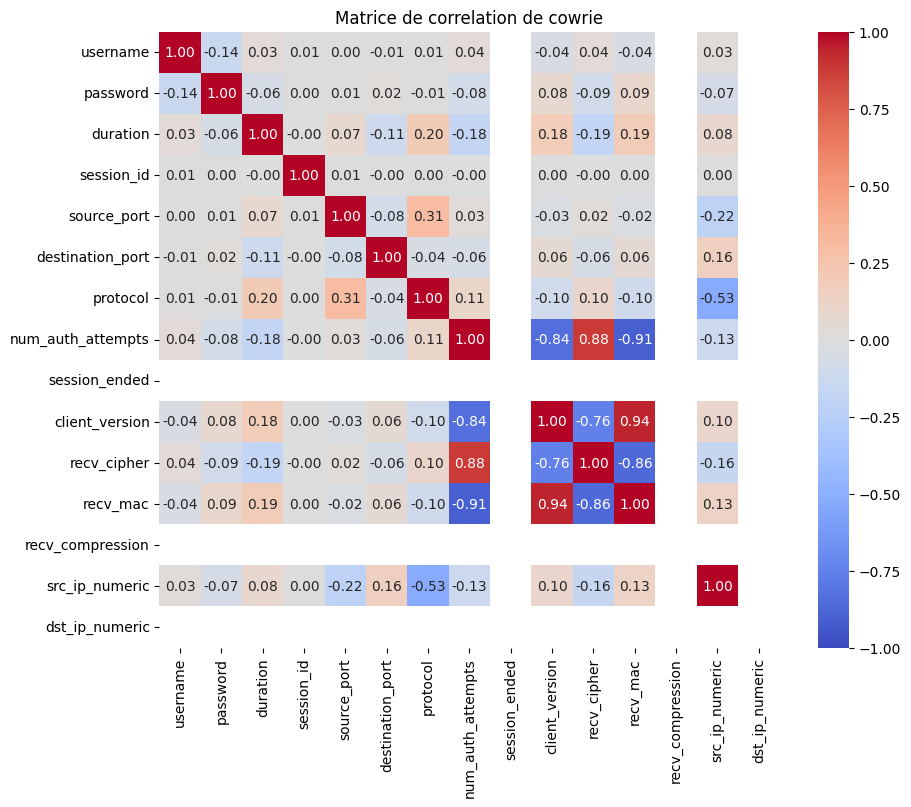

In [60]:
figure(figsize=(10,8))
corr=heraldine.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1.0,fmt='.2f')
plt.title('Matrice de correlation de cowrie')
plt.show()

In [61]:
heraldine.session_ended.value_counts()

,count
session_ended,
0,40646


In [62]:
heraldine.drop(['session_ended','recv_compression','dst_ip_numeric' ], axis=1, inplace=True)

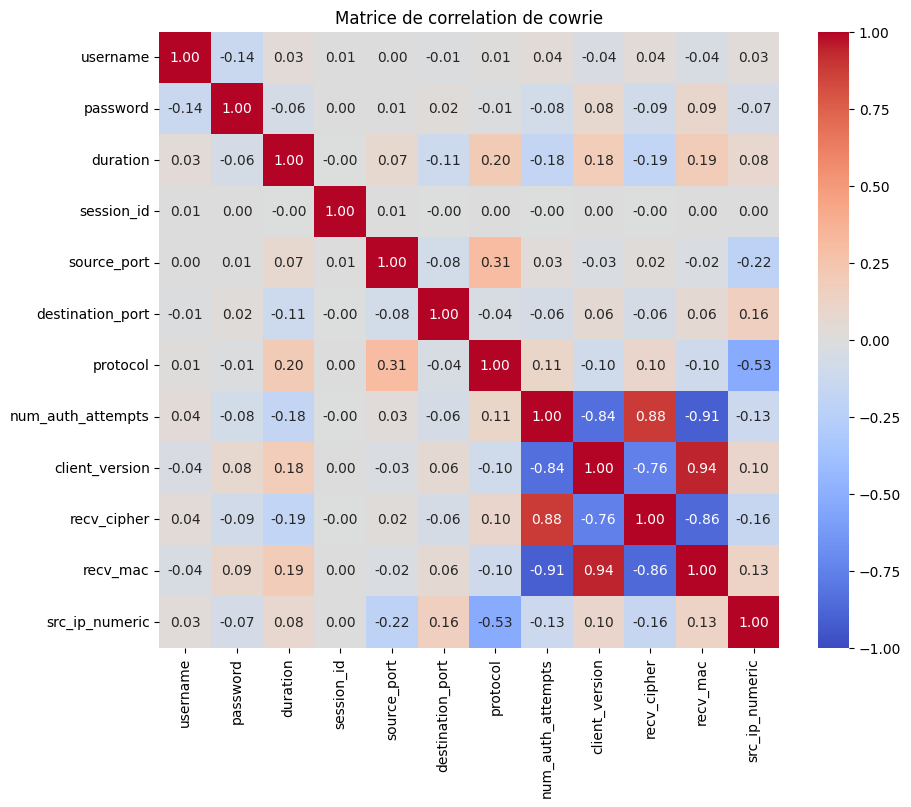

In [63]:
figure(figsize=(10,8))
corr=heraldine.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1.0,fmt='.2f')
plt.title('Matrice de correlation de cowrie')
plt.show()

In [64]:


from sklearn.cluster import KMeans
# Appliquer K-Means pour le clustering
kmeans = KMeans(n_clusters=2, random_state=0)
data['label'] = kmeans.fit_predict(data)
data= pd.DataFrame(data)
# Afficher les données avec les clusters
data


,username,password,duration,session_id,source_port,destination_port,protocol,num_auth_attempts,session_ended,client_version,recv_cipher,recv_mac,recv_compression,src_ip_numeric,dst_ip_numeric,label
0,0.250269,0.034693,0.000000,0.462123,0.259553,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.862404,0.0,0
1,0.023631,0.327754,0.000000,0.885619,0.703740,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.355893,0.0,0
2,0.250269,0.034693,0.000000,0.256957,0.712118,1.000000,1.000000,0.0,0.0,1.0,0.5,0.8,0.0,0.991567,0.0,1
3,0.680988,0.010651,0.000000,0.956846,0.023907,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.829242,0.0,0
4,0.355532,0.552343,0.000000,0.718022,0.128163,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.862404,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40641,0.680988,0.020694,0.000000,0.939599,0.900818,0.071623,0.083333,0.0,0.0,1.0,0.5,0.8,0.0,0.829242,0.0,0
40642,0.680988,0.020694,0.133333,0.700480,0.805079,0.000000,0.833333,0.0,0.0,1.0,0.5,0.8,0.0,0.525468,0.0,1
40643,0.680988,0.020694,0.133333,0.159774,0.919885,0.000000,0.833333,0.0,0.0,1.0,0.5,0.8,0.0,0.525468,0.0,1
40644,0.680988,0.020694,0.100000,0.568360,0.555797,0.000000,0.833333,0.0,0.0,1.0,0.5,0.8,0.0,0.525468,0.0,1


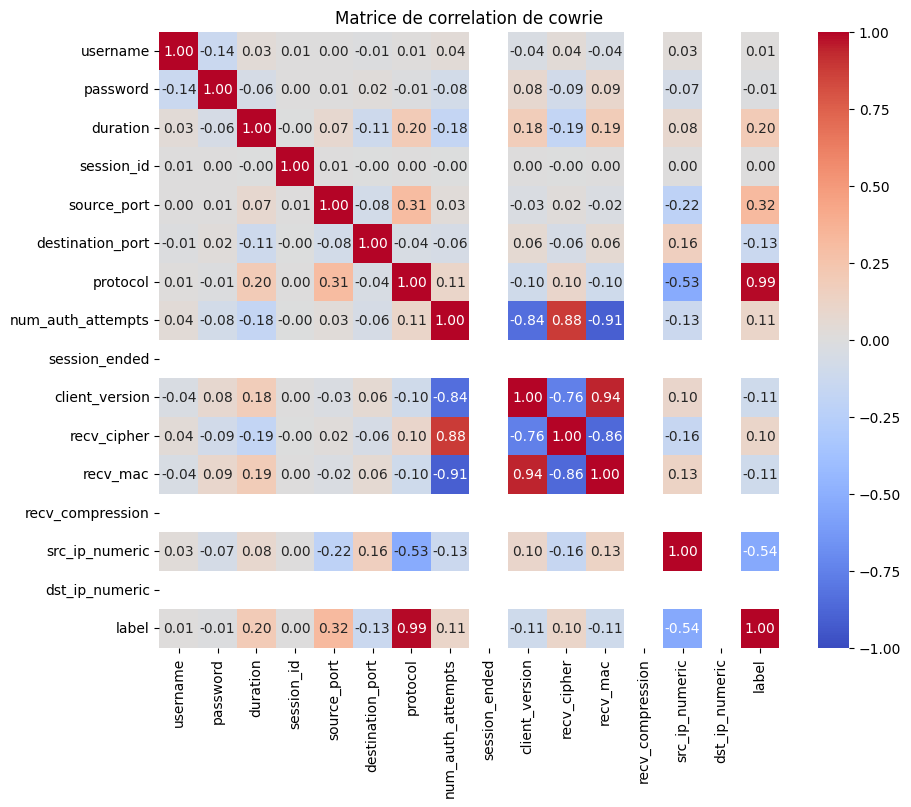

In [65]:
figure(figsize=(10,8))
corr=data.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1.0,fmt='.2f')
plt.title('Matrice de correlation de cowrie')
plt.show()

In [66]:
data.drop(['protocol'], axis=1, inplace=True)

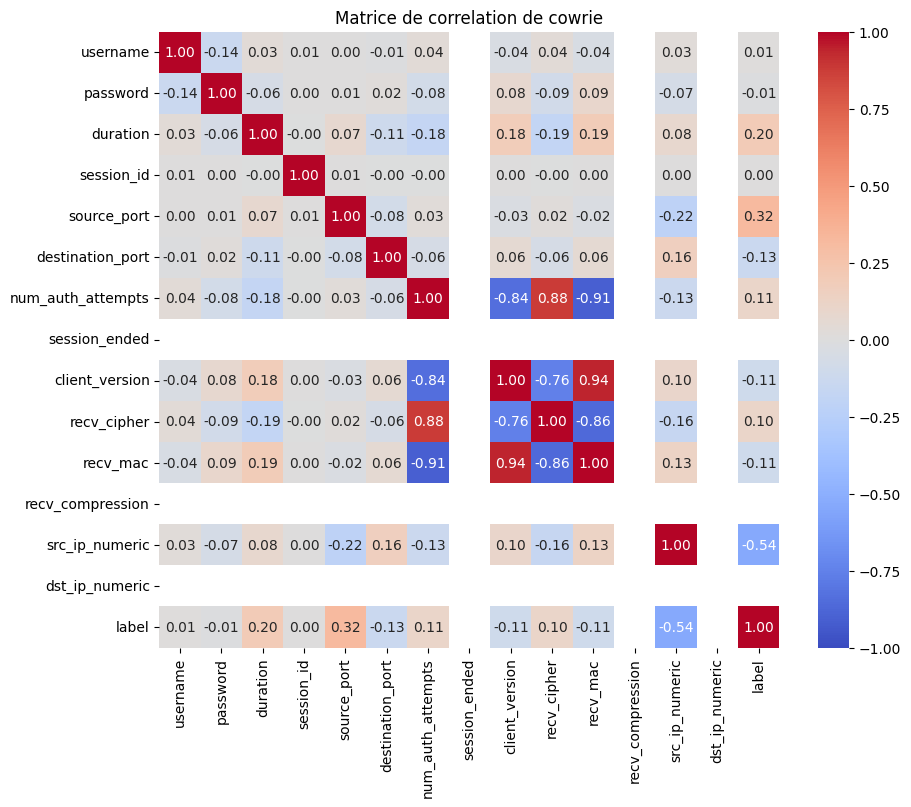

In [67]:
figure(figsize=(10,8))
corr=data.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1.0,fmt='.2f')
plt.title('Matrice de correlation de cowrie')
plt.show()

In [68]:
data.label.value_counts()

,count
label,
1,36919
0,3727


<Axes: >

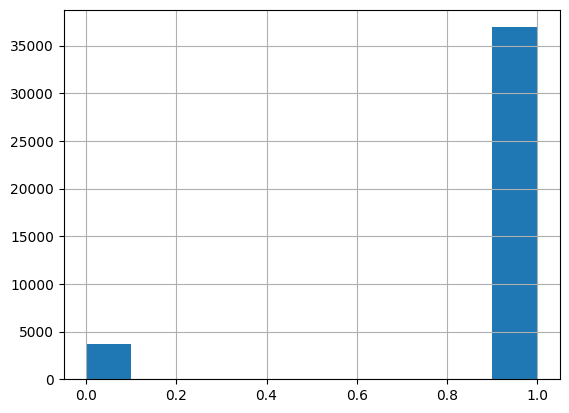

In [69]:
data.label.hist()

In [70]:
X  = data.drop(['label'], axis=1)
y = data['label']

In [71]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler()
X, y = ros.fit_resample(X, y)


In [72]:
data= pd.concat([X, y], axis=1)
data

,username,password,duration,session_id,source_port,destination_port,num_auth_attempts,session_ended,client_version,recv_cipher,recv_mac,recv_compression,src_ip_numeric,dst_ip_numeric,label
0,0.250269,0.034693,0.0,0.462123,0.259553,0.071623,0.0,0.0,1.0,0.5,0.8,0.0,0.862404,0.0,0
1,0.023631,0.327754,0.0,0.885619,0.703740,0.071623,0.0,0.0,1.0,0.5,0.8,0.0,0.355893,0.0,0
2,0.250269,0.034693,0.0,0.256957,0.712118,1.000000,0.0,0.0,1.0,0.5,0.8,0.0,0.991567,0.0,1
3,0.680988,0.010651,0.0,0.956846,0.023907,0.071623,0.0,0.0,1.0,0.5,0.8,0.0,0.829242,0.0,0
4,0.355532,0.552343,0.0,0.718022,0.128163,0.071623,0.0,0.0,1.0,0.5,0.8,0.0,0.862404,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73833,0.680988,0.796105,0.0,0.974831,0.142824,0.071623,0.0,0.0,1.0,0.5,0.8,0.0,0.163583,0.0,0
73834,0.890440,0.020694,0.0,0.644999,0.699040,0.071623,0.0,0.0,1.0,0.5,0.8,0.0,0.829242,0.0,0
73835,0.861439,0.926354,0.0,0.632895,0.809703,0.071623,0.0,0.0,1.0,0.5,0.8,0.0,0.355893,0.0,0
73836,0.680988,0.107425,0.2,0.055899,0.863816,0.071623,0.0,0.0,1.0,0.5,0.8,0.0,0.738704,0.0,0


In [76]:
data.to_csv('heraldine_final.csv', index=False)
print("Le fichier CSV a été enregistré avec succès.")

Le fichier CSV a été enregistré avec succès.


In [77]:
y.value_counts()

,count
label,
0,36919
1,36919


<Axes: >

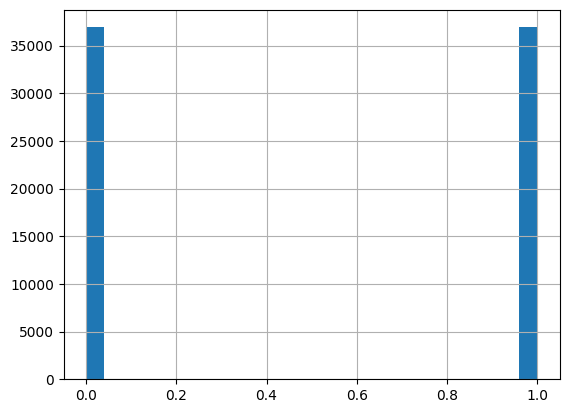

In [83]:
y.hist(bins=25)

In [84]:
# Division des données en ensembles d'entraînement et de test
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score,recall_score, precision_score, confusion_matrix,ConfusionMatrixDisplay ,classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



Accuracy: 1.00

Métriques pour l arbre de decision :
Exactitude : 99.97 %
Précision : 100.0 %
Rappel : 99.95 %
Matrice de confusion :
 [[7384    0]
 [   4 7380]]


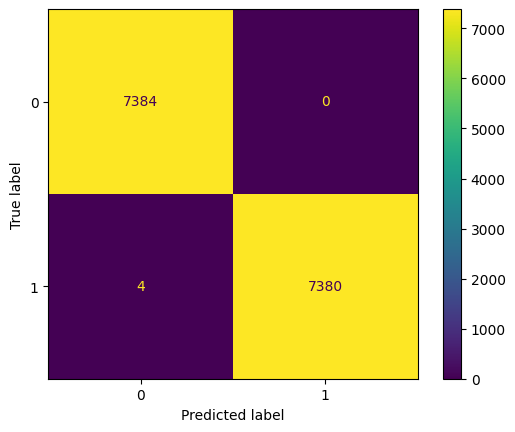

In [85]:
# Entraînement du modèle Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Prédiction et évaluation
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")




matri=confusion_matrix(y_test, y_pred)

print("\nMétriques pour l arbre de decision :")
print("Exactitude :", round(accuracy_score(y_test, y_pred),4)*100,'%')
print("Précision :", round(precision_score(y_test, y_pred),4)*100,'%')
print("Rappel :", round(recall_score(y_test, y_pred),4)*100,'%')
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=matri, display_labels=rf.classes_)
disp.plot()
plt.show()

In [86]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:33:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7384
           1       1.00      1.00      1.00      7384

    accuracy                           1.00     14768
   macro avg       1.00      1.00      1.00     14768
weighted avg       1.00      1.00      1.00     14768



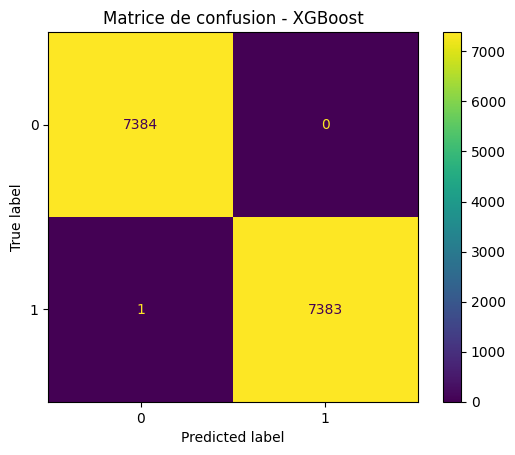


SVM - Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7384
           1       0.97      0.99      0.98      7384

    accuracy                           0.98     14768
   macro avg       0.98      0.98      0.98     14768
weighted avg       0.98      0.98      0.98     14768



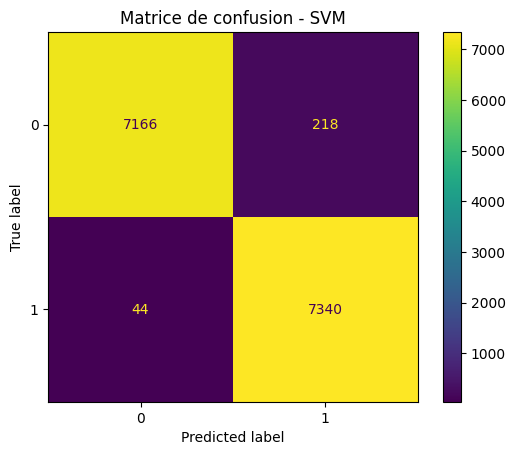


Neural Network - Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7384
           1       1.00      0.99      1.00      7384

    accuracy                           1.00     14768
   macro avg       1.00      1.00      1.00     14768
weighted avg       1.00      1.00      1.00     14768



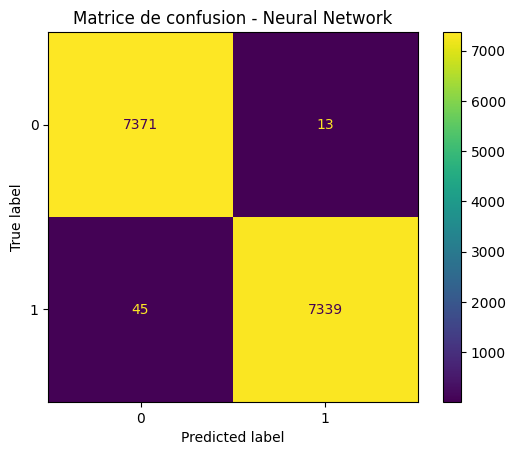


Résumé des performances :
XGBoost: Accuracy = 1.00, ROC AUC = 1.00
SVM: Accuracy = 0.98, ROC AUC = 0.99
Neural Network: Accuracy = 1.00, ROC AUC = 1.00


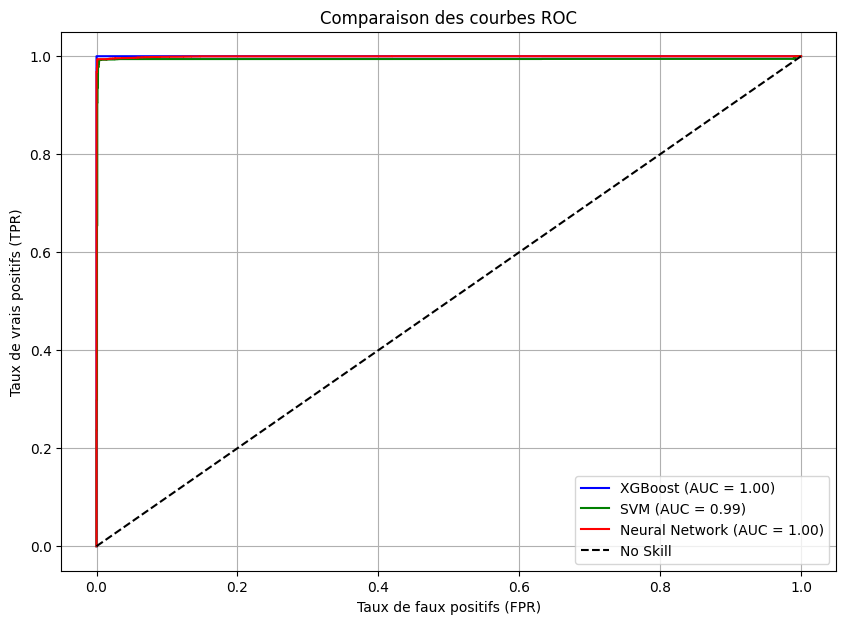

In [87]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

'''
# 1. Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
'''
# 3. Modèles
models = {
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42
    ),
    "SVM": SVC(kernel='rbf', cache_size=10, probability=True, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(5, 5), max_iter=200, random_state=42)
}

# 4. Entraînement & Évaluation
results = {}
for name, model in models.items():
    X_train_input = X_train if name in ["SVM", "Neural Network"] else X_train
    X_test_input = X_test if name in ["SVM", "Neural Network"] else X_test

    model.fit(X_train_input, y_train)
    y_pred = model.predict(X_test_input)
    y_pred_prob = model.predict_proba(X_test_input)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    results[name] = {"Accuracy": accuracy, "ROC AUC": roc_auc}

    print(f"\n{name} - Classification Report:")
    print(classification_report(y_test, y_pred))

    matri = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matri, display_labels=model.classes_)
    disp.plot()
    plt.title(f"Matrice de confusion - {name}")
    plt.show()

# 5. Résumé des performances
print("\nRésumé des performances :")
for name, metrics in results.items():
    print(f"{name}: Accuracy = {metrics['Accuracy']:.2f}, ROC AUC = {metrics['ROC AUC']:.2f}")

# 6. Courbes ROC
colors = {"XGBoost": "blue", "SVM": "green", "Neural Network": "red"}

plt.figure(figsize=(10, 7))
for name, model in models.items():
    X_test_input = X_test if name in ["SVM", "Neural Network"] else X_test
    y_pred_prob = model.predict_proba(X_test_input)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['ROC AUC']:.2f})", color=colors[name])

plt.plot([0, 1], [0, 1], 'k--', label="No Skill")
plt.title("Comparaison des courbes ROC")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
